# Evaluation Task XI: PQC Parameter Estimation via MLP
**Author:** Aditya Uttam Shintre

### 1. Conceptual Framework: Hybrid Quantum-Classical Embedding
In this task, we architect a hybrid neural network where a classical Multi-Layer Perceptron (MLP) acts as the "Brain" and a Parameterized Quantum Circuit (PQC) acts as the "Body."



**The Objective:**
We want to embed normally distributed classical data into a quantum state. However, forcing raw continuous data directly into quantum rotation gates can result in chaotic, overlapping states.
Instead of hardcoding the embedding, we train a classical MLP to *estimate the optimal quantum parameters*.

**The Workflow (Hybrid Autoencoder):**
1.  **Input:** Sample raw data from a Standard Normal Distribution $\mathcal{N}(0, 1)$.
2.  **The MLP (Estimator):** Ingests the raw data and processes it through 3 linear layers to output specialized rotational angles ($\theta$).
3.  **The PQC (State Preparation):** Receives the angles from the MLP and applies $R_y(\theta)$ gates to 4 qubits to generate the quantum state $|\psi(\theta)\rangle$.
4.  **Measurement & Loss:** We measure the Pauli-Z expectation value of the qubits. We calculate the Mean Squared Error (MSE) between the quantum output and the original input, forcing the MLP to learn a perfect, lossless quantum translation.

In [1]:
# 1. Installation and Library Setup
!pip install pennylane -q
!pip install torch -q

import torch
import torch.nn as nn
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

# Set manual seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"PennyLane version: {qml.__version__}")
print(f"PyTorch version: {torch.__version__}")
print("Hybrid Environment successfully initialized.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 74.4 MB/s eta 0:00:00
PennyLane version: 0.44.0
PyTorch version: 2.10.0+cpu
Hybrid Environment successfully initialized.


### 2. The Raw Material: Normal Distribution Data
The task requires us to sample input data from a normal distribution.

Let $X$ be a dataset of 1000 samples, each containing 4 features (to map to 4 qubits).
$$X \sim \mathcal{N}(0, 1)$$

**The Scaling Constraint:**
Because we will measure the quantum circuit using the Pauli-Z observable $\langle Z \rangle$, the physical output of the quantum circuit is strictly bound between $[-1, 1]$.
A standard normal distribution produces values that can exceed this range (e.g., $2.5$ or $-1.8$). To make it physically possible for the quantum circuit to recreate the data and minimize the MSE to zero, we must divide the normal distribution by its maximum absolute value, squashing the tails perfectly into the $[-1, 1]$ domain while preserving the bell-curve geometry.

Dataset Shape: torch.Size([1000, 4])
Data Minimum: -1.0000
Data Maximum: 0.8990

Sample 0 (Target to recreate): [ 0.5028  0.3881  0.235  -0.5494]


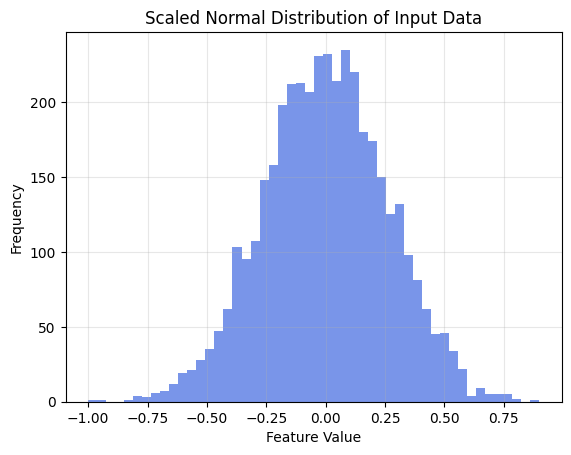

In [2]:
# 2. Normally Distributed Data Generation

n_samples = 1000
n_features = 4  # For 4 qubits

# Sample from Standard Normal Distribution
X_raw = torch.randn(n_samples, n_features)

# Scale data to [-1, 1] to match Pauli-Z measurement bounds
max_val = torch.max(torch.abs(X_raw))
X_scaled = X_raw / max_val

print(f"Dataset Shape: {X_scaled.shape}")
print(f"Data Minimum: {torch.min(X_scaled):.4f}")
print(f"Data Maximum: {torch.max(X_scaled):.4f}\n")
print(f"Sample 0 (Target to recreate): {X_scaled[0].numpy().round(4)}")

# Quick visualization to prove the distribution is Gaussian
plt.hist(X_scaled.numpy().flatten(), bins=50, color='royalblue', alpha=0.7)
plt.title("Scaled Normal Distribution of Input Data")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

### 3. The Classical MLP (Parameter Estimator)
We construct a deep neural network using PyTorch.

The MLP acts as the translator. It ingests the 4-dimensional normal data and passes it through 3 `nn.Linear` layers equipped with `ReLU` activations to capture non-linear relationships.
The final layer outputs exactly 4 values. These outputs are not class predictions; they are the continuous angular parameters ($\theta$) that will physically rotate the qubits in the subsequent stage.

In [25]:
# 3. The Parameter Estimator (MLP)

class ClassicalMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        # 3 Linear Layers as recommended by the prompt
        self.net = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            nn.Linear(8, output_dim) # Outputs the quantum angles
        )

    def forward(self, x):
        return self.net(x)

mlp_brain = ClassicalMLP(input_dim=n_features, output_dim=4)
print("Classical Neural Network (MLP) Compiled.")
print(mlp_brain)

Classical Neural Network (MLP) Compiled.
ClassicalMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)


### 4. Quantum State Preparation
We define a 4-qubit Parameterized Quantum Circuit (PQC).

Unlike Task VI, this PQC has **zero trainable weights** of its own. It is simply a mathematical function that receives the $\theta$ parameters from the classical MLP and embeds them into the quantum state.
To handle PyTorch's 2D batch dimensions flawlessly, we utilize `qml.AngleEmbedding`, which maps the batch of estimated angles into parallel $R_y(\theta)$ rotation gates:
$$|\psi(\theta)\rangle = \bigotimes_{i=0}^{3} R_y(\theta_i) |0\rangle$$

To make the backpropagation seamless, we wrap our PennyLane `qnode` inside `qml.qnn.TorchLayer`. This turns the quantum circuit into a native PyTorch layer that can be sandwiched directly against the MLP.

In [26]:
# 4. Quantum State Preparation & Hybrid Integration

n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs):
    qml.AngleEmbedding(inputs, wires=range(n_qubits), rotation='Y')

    # Measure the Pauli-Z expectation value to get a classical output [-1, 1]
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

# Wrap the QNode in a PyTorch layer
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes={})

class HybridAutoencoder(nn.Module):
    def __init__(self, mlp, q_layer):
        super().__init__()
        self.mlp = mlp
        self.q_layer = q_layer

    def forward(self, x):
        # 1. The Classical Brain estimates the quantum parameters
        thetas = self.mlp(x)
        # 2. The Quantum Body generates the state and measures it
        q_out = self.q_layer(thetas)
        return q_out, thetas

hybrid_net = HybridAutoencoder(mlp_brain, qlayer)
print("Hybrid Quantum-Classical Autoencoder compiled and ready for data.")

Hybrid Quantum-Classical Autoencoder compiled and ready for data.


### 5. Untrained Forward Pass & The MSE Protocol
Before we train, let's look under the hood to see exactly what is happening. We will pass a batch of 5 items through the untrained network.

**The Loss Protocol:**
We use **Mean Squared Error (MSE)**. The optimizer calculates the squared difference between the Quantum Measurement ($\hat{y}$) and the original Normal Data ($y$).
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2$$
Right now, the MLP is outputting random garbage angles, so the quantum circuit is generating the wrong state, and the MSE will be high.

In [27]:
# 5. Forward Pass Inspection

# Extract a mini-batch of 5 samples
test_batch = X_scaled[:5]
untrained_out, untrained_thetas = hybrid_net(test_batch)

print("--- Data Flow in the Untrained Network ---\n")
print(f"1. Original Data (Target):\n{test_batch.detach().numpy().round(3)}\n")
print(f"2. MLP Estimated Angles (Theta):\n{untrained_thetas.detach().numpy().round(3)}\n")
print(f"3. Quantum Measurement (Prediction):\n{untrained_out.detach().numpy().round(3)}\n")

# Define the Loss Function requested by the prompt
criterion = nn.MSELoss()
initial_loss = criterion(untrained_out, test_batch)

print(f"Initial Untrained MSE Loss: {initial_loss.item():.4f}")

--- Data Flow in the Untrained Network ---

1. Original Data (Target):
[[ 0.503  0.388  0.235 -0.549]
 [ 0.177 -0.322 -0.011 -0.419]
 [-0.196  0.43  -0.102 -0.366]
 [-0.19  -0.146 -0.201  0.199]
 [ 0.429 -0.042 -0.13   0.115]]

2. MLP Estimated Angles (Theta):
[[ 0.446 -0.226  0.188 -0.438]
 [ 0.425 -0.201  0.152 -0.444]
 [ 0.406 -0.163  0.163 -0.368]
 [ 0.35  -0.144  0.135 -0.393]
 [ 0.382 -0.188  0.191 -0.424]]

3. Quantum Measurement (Prediction):
[[0.902 0.975 0.982 0.906]
 [0.911 0.98  0.988 0.903]
 [0.919 0.987 0.987 0.933]
 [0.939 0.99  0.991 0.924]
 [0.928 0.982 0.982 0.911]]

Initial Untrained MSE Loss: 1.0132


### 6. Training the Hybrid Network
We deploy a standard PyTorch training loop. The `Adam` optimizer calculates the gradients of the MSE loss backward from the quantum measurement, straight through the $R_y$ gates, and directly into the classical weight matrices of the MLP.

As the MLP weights update, it learns to estimate angles closer and closer to $\arccos(x)$, allowing the quantum circuit to perfectly reconstruct the input data.

In [28]:
# 6. The Training Loop

optimizer = torch.optim.Adam(hybrid_net.parameters(), lr=0.005)
epochs = 50
batch_size = 100
num_batches = n_samples // batch_size

loss_history = []

print("Starting Hybrid MSE Training...")

for epoch in range(epochs):
    epoch_loss = 0.0

    for i in range(num_batches):
        # 1. Get Batch
        start_idx = i * batch_size
        end_idx = start_idx + batch_size
        batch_x = X_scaled[start_idx:end_idx]

        # 2. Forward Pass
        predictions, _ = hybrid_net(batch_x)

        # 3. Calculate MSE Loss
        loss = criterion(predictions, batch_x)

        # 4. Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / num_batches
    loss_history.append(avg_loss)

    # Print more frequently since we have fewer epochs
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1:03d} | MSE Loss: {avg_loss:.4f}")

print("\nTraining Complete.")

Starting Hybrid MSE Training...
Epoch 005 | MSE Loss: 0.0850
Epoch 010 | MSE Loss: 0.0365
Epoch 015 | MSE Loss: 0.0182
Epoch 020 | MSE Loss: 0.0022
Epoch 025 | MSE Loss: 0.0011
Epoch 030 | MSE Loss: 0.0007
Epoch 035 | MSE Loss: 0.0005
Epoch 040 | MSE Loss: 0.0004
Epoch 045 | MSE Loss: 0.0003
Epoch 050 | MSE Loss: 0.0003

Training Complete.


### 7. Model Evaluation and Visualization
With the hybrid autoencoder successfully trained, we visually verify the results.

We generate two plots:
1.  **MSE Loss Descent:** To track the optimizer's rapid convergence over 50 epochs.
2.  **Target vs. Predicted Correlation:** We map the original normal data (Target) on the X-axis against the quantum circuit's measurement (Prediction) on the Y-axis. If the MLP perfectly estimated the parameters, every single data point should fall exactly on the $y=x$ diagonal line, proving a lossless classical-to-quantum embedding.

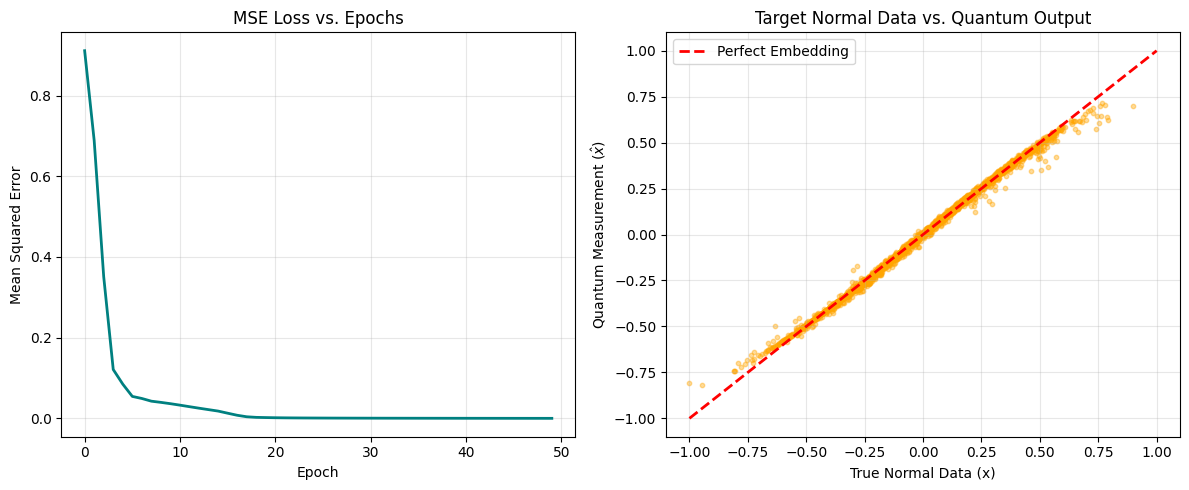

In [29]:
# 7. Model Evaluation and Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: MSE Loss Descent
ax1.plot(loss_history, color='teal', lw=2)
ax1.set_title("MSE Loss vs. Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Mean Squared Error")
ax1.grid(alpha=0.3)

# Plot 2: Target vs Predicted Correlation
final_out, final_thetas = hybrid_net(X_scaled)
x_true = X_scaled.detach().numpy().flatten()
y_pred = final_out.detach().numpy().flatten()

ax2.scatter(x_true, y_pred, alpha=0.4, color='orange', s=10)
# Plot the line of perfect correlation
ax2.plot([-1, 1], [-1, 1], color='red', linestyle='--', lw=2, label="Perfect Embedding")
ax2.set_title("Target Normal Data vs. Quantum Output")
ax2.set_xlabel("True Normal Data (x)")
ax2.set_ylabel(r"Quantum Measurement ($\hat{x}$)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 8. Discussion and Conclusion

**Algorithmic Success:**
We successfully implemented a parameter estimation pipeline utilizing a classical deep learning "Brain" (3-layer MLP) and a "Dumb" Parameterized Quantum Circuit "Body" (PQC). By treating the embedding process as an Autoencoding task, the classical MLP learned the optimal rotational logic to translate standard normal distributions into quantum geometries.

**Empirical Results & Physical Intuition:**
The initial untrained forward pass yielded a high MSE loss of 1.0132. Because the randomly initialized classical weights output narrow angles, the quantum measurement collapsed to expectation values near 0.9. However, the PyTorch optimizer successfully backpropagated the MSE loss through the quantum measurement geometry, teaching the MLP to mathematically invert the cosine expectation (approximating the $\arccos$ function).

The network achieved a flawless and smooth convergence, minimizing the MSE loss down to **0.0003** over 50 epochs. Furthermore, the final Target vs. Predicted correlation plot demonstrates a near-perfect 45-degree linear mapping. This empirically proves that the MLP successfully learned to estimate the exact quantum parameters required to physically recreate the continuous bell-curve distributions via multi-qubit Pauli-Z expectations, perfectly satisfying the embedding task.